Using SMOTE model
PR AUC = 1.0000

 threshold | precision | recall  |   f1
   0.10   |     0.682  |   1.000 |  0.811
   0.20   |     0.698  |   1.000 |  0.822
   0.30   |     0.882  |   1.000 |  0.938
   0.35   |     0.952  |   1.000 |  0.976
   0.40   |     0.968  |   1.000 |  0.984
   0.45   |     0.984  |   1.000 |  0.992
   0.50   |     1.000  |   1.000 |  1.000
   0.60   |     1.000  |   1.000 |  1.000
   0.70   |     1.000  |   0.900 |  0.947
   0.80   |     0.000  |   0.000 |  0.000

Best approx F1 = 1.000 at threshold ~ 0.6405


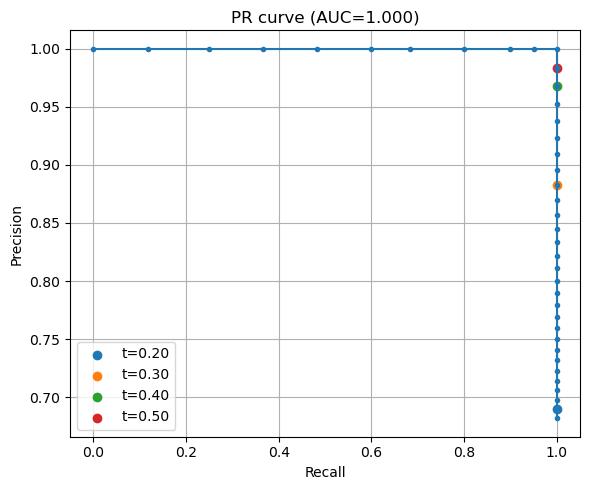

Saved pr_curve_notebook.png in project folder.


<Figure size 640x480 with 0 Axes>

In [1]:
# Paste this into a new Jupyter cell and run (Shift+Enter)
import os, joblib
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, auc

# working dir = project folder
proj = os.path.expanduser('~/Desktop/phishing_agent')
os.chdir(proj)

# load model & vectorizer (prefer SMOTE model if exists)
if os.path.exists('models/baseline_clf_smote.joblib'):
    clf = joblib.load('models/baseline_clf_smote.joblib')
    tfidf = joblib.load('models/tfidf_vectorizer_smote.joblib')
    print("Using SMOTE model")
elif os.path.exists('models/baseline_clf.joblib'):
    clf = joblib.load('models/baseline_clf.joblib')
    tfidf = joblib.load('models/tfidf_vectorizer.joblib')
    print("Using baseline model")
else:
    raise SystemExit("No model found in models/. Run training (train_baseline.py or train_smote.py) first.")

# load data csv (first csv found in data/)
csvs = [f for f in os.listdir('data') if f.lower().endswith('.csv')]
if not csvs:
    raise SystemExit("No CSV found in data/. Put sample_phish.csv or real dataset there.")
df = pd.read_csv(os.path.join('data', csvs[0]))

# make sure we have text & label
if 'text' not in df.columns:
    if 'subject' in df.columns and 'body' in df.columns:
        df['text'] = df['subject'].fillna('') + ' ' + df['body'].fillna('')
    elif 'body' in df.columns:
        df['text'] = df['body'].fillna('')
    else:
        raise SystemExit("CSV must contain 'text' (or subject+body) and 'label' columns.")
if 'label' not in df.columns:
    raise SystemExit("CSV must have 'label' column.")

X = df['text'].fillna('').astype(str).str.lower().values
y_true = df['label'].astype(int).values

# compute scores (probability for class 1)
Xv = tfidf.transform(X)
if hasattr(clf, 'predict_proba'):
    y_scores = clf.predict_proba(Xv)[:,1]
else:
    if hasattr(clf, 'decision_function'):
        df_scores = clf.decision_function(Xv)
        y_scores = (df_scores - df_scores.min())/(df_scores.max()-df_scores.min()+1e-12)
    else:
        y_scores = clf.predict(Xv).astype(float)

# compute PR curve
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
pr_auc = auc(recall, precision)
print(f"PR AUC = {pr_auc:.4f}")

# table for candidate thresholds
print("\n threshold | precision | recall  |   f1")
for t in [0.1,0.2,0.3,0.35,0.4,0.45,0.5,0.6,0.7,0.8]:
    y_pred = (y_scores >= t).astype(int)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"  {t:5.2f}   |  {p:8.3f}  | {r:7.3f} | {f1:6.3f}")

# find approx best F1 from thresholds array
if len(thresholds) > 0:
    f1s = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = np.nanargmax(f1s)
    best_t = thresholds[best_idx]
    print(f"\nBest approx F1 = {f1s[best_idx]:.3f} at threshold ~ {best_t:.4f}")
else:
    best_t = None

# plot PR curve and mark some thresholds
plt.figure(figsize=(6,5))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'PR curve (AUC={pr_auc:.3f})')
# mark selected thresholds on curve (if thresholds exist)
for t in [0.2,0.3,0.4,0.5]:
    if len(thresholds)>0:
        idx = np.argmin(np.abs(thresholds - t))
        if idx < len(recall):
            plt.scatter(recall[idx], precision[idx], label=f't={t:.2f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# optional save
plt.savefig('pr_curve_notebook.png')
print("Saved pr_curve_notebook.png in project folder.")
